Created base on this:
https://www.datacamp.com/tutorial/pyspark-tutorial-getting-started-with-pyspark

In [63]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import time
import os

# create spark session

In [100]:
spark = (
    SparkSession
    .builder
    .appName('spark-local')
    .master('local[8]')
    .config('spark.memory.offHeap.enabled', 'true')
    .config('spark.memory.offHeap.size', '1g')
    .getOrCreate()
)

# spark.conf.set('spark.default.parallelism', 4)
# spark.conf.set('spark.sql.shuffle.partitions', 4)

def sp_shape(df):
    return (df.count(), len(df.columns))
def sp_show(df):
    print(sp_shape(df))
    df.show(5,0)

In [99]:
spark.stop()

In [65]:
print(spark.conf.get('spark.sql.shuffle.partitions'))

200


# load data

In [101]:
t0 = time.time()
d = spark.read.csv('c:/test/data/online_retail.csv', header=True, escape='\"')
#d = spark.read.parquet('c:/test/elchapo/position-20230622000009.parquet')
d.show(5,0)
print(f'time: {time.time() - t0:.3f}')

+---------+---------+-----------------------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate   |UnitPrice|CustomerID|Country       |
+---------+---------+-----------------------------------+--------+--------------+---------+----------+--------------+
|536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |1/12/2010 8:26|2.55     |17850     |United Kingdom|
|536365   |71053    |WHITE METAL LANTERN                |6       |1/12/2010 8:26|3.39     |17850     |United Kingdom|
|536365   |84406B   |CREAM CUPID HEARTS COAT HANGER     |8       |1/12/2010 8:26|2.75     |17850     |United Kingdom|
|536365   |84029G   |KNITTED UNION FLAG HOT WATER BOTTLE|6       |1/12/2010 8:26|3.39     |17850     |United Kingdom|
|536365   |84029E   |RED WOOLLY HOTTIE WHITE HEART.     |6       |1/12/2010 8:26|3.39     |17850     |United Kingdom|
+---------+---------+-----------------------------------

In [74]:
print(sp_shape(d))
print(d.printSchema())
d.summary().show() #will return None

(541909, 8)
root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: string (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: string (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)

None
+-------+------------------+------------------+--------------------+------------------+---------------+-----------------+------------------+-----------+
|summary|         InvoiceNo|         StockCode|         Description|          Quantity|    InvoiceDate|        UnitPrice|        CustomerID|    Country|
+-------+------------------+------------------+--------------------+------------------+---------------+-----------------+------------------+-----------+
|  count|            541909|            541909|              540455|            541909|         541909|           541909|            406829|     541909|
|   mean|  559965.752026781|27623.2

In [102]:
t0 = time.time()
d.withColumn('cd', when(col('InvoiceNo').isin([536365, 541909]), col('CustomerID')).otherwise(col('Country'))).show(5,0)
print(f'time: {time.time() - t0:.3f}')

+---------+---------+-----------------------------------+--------+--------------+---------+----------+--------------+-----+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate   |UnitPrice|CustomerID|Country       |cd   |
+---------+---------+-----------------------------------+--------+--------------+---------+----------+--------------+-----+
|536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |1/12/2010 8:26|2.55     |17850     |United Kingdom|17850|
|536365   |71053    |WHITE METAL LANTERN                |6       |1/12/2010 8:26|3.39     |17850     |United Kingdom|17850|
|536365   |84406B   |CREAM CUPID HEARTS COAT HANGER     |8       |1/12/2010 8:26|2.75     |17850     |United Kingdom|17850|
|536365   |84029G   |KNITTED UNION FLAG HOT WATER BOTTLE|6       |1/12/2010 8:26|3.39     |17850     |United Kingdom|17850|
|536365   |84029E   |RED WOOLLY HOTTIE WHITE HEART.     |6       |1/12/2010 8:26|3.39     |17850     |United Kingdom|17850|
+-------

In [103]:
t0 = time.time()
#convert col types
d1 = (
    d
    .withColumn('InvoiceNo', col('InvoiceNo').cast('int'))
    .withColumn('StockCode', col('StockCode').cast('int'))
    .withColumn('Quantity', col('Quantity').cast('double'))
    .withColumn('UnitPrice', col('UnitPrice').cast('double'))  
    .withColumn('InvoiceDate', to_timestamp('InvoiceDate', 'd/M/yyyy H:mm'))   
    .withColumn('CustomerID', col('CustomerID').cast('int'))
)
d1.show(5,0)
print(f'time: {time.time() - t0:.3f}')

+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate        |UnitPrice|CustomerID|Country       |
+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+
|536365   |null     |WHITE HANGING HEART T-LIGHT HOLDER |6.0     |2010-12-01 08:26:00|2.55     |17850     |United Kingdom|
|536365   |71053    |WHITE METAL LANTERN                |6.0     |2010-12-01 08:26:00|3.39     |17850     |United Kingdom|
|536365   |null     |CREAM CUPID HEARTS COAT HANGER     |8.0     |2010-12-01 08:26:00|2.75     |17850     |United Kingdom|
|536365   |null     |KNITTED UNION FLAG HOT WATER BOTTLE|6.0     |2010-12-01 08:26:00|3.39     |17850     |United Kingdom|
|536365   |null     |RED WOOLLY HOTTIE WHITE HEART.     |6.0     |2010-12-01 08:26:00|3.39     |17850     |United Kingdom|
+---------+-----

In [104]:
t0 = time.time()
d1.describe().show()
print(f'time: {time.time() - t0:.3f}')

+-------+-----------------+------------------+--------------------+-----------------+-----------------+------------------+-----------+
|summary|        InvoiceNo|         StockCode|         Description|         Quantity|        UnitPrice|        CustomerID|    Country|
+-------+-----------------+------------------+--------------------+-----------------+-----------------+------------------+-----------+
|  count|           532618|            487036|              540455|           541909|           541909|            406829|     541909|
|   mean| 559965.752026781|27089.272460352007|             20713.0| 9.55224954743324|4.611113626089749|15287.690570239585|       null|
| stddev|13428.41728079586|15977.952954078411|                null|218.0811578502342|96.75985306117957|1713.6003033216011|       null|
|    min|           536365|             10002| 4 PURPLE FLOCK D...|         -80995.0|        -11062.06|             12346|  Australia|
|    max|           581587|             90208|   wrongl

In [105]:
t0 = time.time()
d1.summary().show()
print(f'time: {time.time() - t0:.3f}')

+-------+-----------------+------------------+--------------------+-----------------+-----------------+------------------+-----------+
|summary|        InvoiceNo|         StockCode|         Description|         Quantity|        UnitPrice|        CustomerID|    Country|
+-------+-----------------+------------------+--------------------+-----------------+-----------------+------------------+-----------+
|  count|           532618|            487036|              540455|           541909|           541909|            406829|     541909|
|   mean| 559965.752026781|27089.272460352007|             20713.0| 9.55224954743324|4.611113626089749|15287.690570239585|       null|
| stddev|13428.41728079586|15977.952954078411|                null|218.0811578502342|96.75985306117957|1713.6003033216011|       null|
|    min|           536365|             10002| 4 PURPLE FLOCK D...|         -80995.0|        -11062.06|             12346|  Australia|
|    25%|           547903|             21928|         

# explore data

In [71]:
d1.select('CustomerID').distinct().count()

4373

In [82]:
d1.agg({'InvoiceDate': 'min', 'InvoiceDate': 'max'}).first()[0]

datetime.datetime(2011, 12, 9, 12, 50)

In [107]:
from pyspark.sql import functions as f
agg = d1.agg(f.min('InvoiceDate').alias('mn'), f.max('InvoiceDate').alias('mx'), f.avg('InvoiceDate').alias('ag'), f.sum('InvoiceDate').alias('sm')).first()

In [109]:
agg[:-1]

(datetime.datetime(2010, 12, 1, 8, 26),
 datetime.datetime(2011, 12, 9, 12, 50),
 1309750497.1563861)

In [110]:
d1.groupBy('Country').agg(countDistinct('CustomerID').alias('country_count')).orderBy(desc('country_count')).show()

+---------------+-------------+
|        Country|country_count|
+---------------+-------------+
| United Kingdom|         3950|
|        Germany|           95|
|         France|           87|
|          Spain|           31|
|        Belgium|           25|
|    Switzerland|           21|
|       Portugal|           19|
|          Italy|           15|
|        Finland|           12|
|        Austria|           11|
|         Norway|           10|
|        Denmark|            9|
|Channel Islands|            9|
|      Australia|            9|
|    Netherlands|            9|
|         Sweden|            8|
|         Cyprus|            8|
|          Japan|            8|
|         Poland|            6|
|         Greece|            4|
+---------------+-------------+
only showing top 20 rows



In [116]:
# spark.sql("set spark.sql.legacy.timeParserPolicy=LEGACY")
# df = df.withColumn('date', to_timestamp("InvoiceDate", 'dd/MM/yyyy HH:mm'))
d1.select(max('InvoiceDate')).show()

+-------------------+
|   max(InvoiceDate)|
+-------------------+
|2011-12-09 12:50:00|
+-------------------+



In [117]:
d1.select(min('InvoiceDate')).show()

+-------------------+
|   min(InvoiceDate)|
+-------------------+
|2010-12-01 08:26:00|
+-------------------+



# pre-process data

In [118]:
d1.show(5,0)

+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate        |UnitPrice|CustomerID|Country       |
+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+
|536365   |null     |WHITE HANGING HEART T-LIGHT HOLDER |6.0     |2010-12-01 08:26:00|2.55     |17850     |United Kingdom|
|536365   |71053    |WHITE METAL LANTERN                |6.0     |2010-12-01 08:26:00|3.39     |17850     |United Kingdom|
|536365   |null     |CREAM CUPID HEARTS COAT HANGER     |8.0     |2010-12-01 08:26:00|2.75     |17850     |United Kingdom|
|536365   |null     |KNITTED UNION FLAG HOT WATER BOTTLE|6.0     |2010-12-01 08:26:00|3.39     |17850     |United Kingdom|
|536365   |null     |RED WOOLLY HOTTIE WHITE HEART.     |6.0     |2010-12-01 08:26:00|3.39     |17850     |United Kingdom|
+---------+-----

## Recency

In [119]:
d2 = d1.withColumn('from_date', to_timestamp(lit('2010-12-01 08:26'), 'yyyy-MM-dd HH:mm'))
d2.show(5,0)

+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+-------------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate        |UnitPrice|CustomerID|Country       |from_date          |
+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+-------------------+
|536365   |null     |WHITE HANGING HEART T-LIGHT HOLDER |6.0     |2010-12-01 08:26:00|2.55     |17850     |United Kingdom|2010-12-01 08:26:00|
|536365   |71053    |WHITE METAL LANTERN                |6.0     |2010-12-01 08:26:00|3.39     |17850     |United Kingdom|2010-12-01 08:26:00|
|536365   |null     |CREAM CUPID HEARTS COAT HANGER     |8.0     |2010-12-01 08:26:00|2.75     |17850     |United Kingdom|2010-12-01 08:26:00|
|536365   |null     |KNITTED UNION FLAG HOT WATER BOTTLE|6.0     |2010-12-01 08:26:00|3.39     |17850     |United Kingdom|2010-12-01 08:26:00|

In [31]:
df = df.withColumn('from_date', lit('2010-12-01 08:26'))
df = df.withColumn('from_date', to_timestamp('from_date', 'yyyy-MM-dd HH:mm'))

d2 = (
    df
    .withColumn('from_date', to_timestamp(col('from_date')))
    .withColumn('recency', col('date').cast('long') - col('from_date').cast('long'))
)

d2 = d2.join(
    d2.groupBy('CustomerID').agg(max('recency').alias('recency')), 
    on='recency', 
    how='leftsemi',
)

d2.show(5,0)

+-------+---------+---------+-----------------------------------+--------+--------------+---------+----------+--------------+-------------------+-------------------+
|recency|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate   |UnitPrice|CustomerID|Country       |date               |from_date          |
+-------+---------+---------+-----------------------------------+--------+--------------+---------+----------+--------------+-------------------+-------------------+
|5220   |536384   |82484    |WOOD BLACK BOARD ANT WHITE FINISH  |3       |1/12/2010 9:53|6.45     |18074     |United Kingdom|2010-12-01 09:53:00|2010-12-01 08:26:00|
|5220   |536384   |84755    |COLOUR GLASS T-LIGHT HOLDER HANGING|48      |1/12/2010 9:53|0.65     |18074     |United Kingdom|2010-12-01 09:53:00|2010-12-01 08:26:00|
|5220   |536384   |22464    |HANGING METAL HEART LANTERN        |12      |1/12/2010 9:53|1.65     |18074     |United Kingdom|2010-12-01 09:53:00|2010-12-01 08:26:00|
|522

In [32]:
d2.printSchema()

root
 |-- recency: long (nullable = true)
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: string (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: string (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- from_date: timestamp (nullable = true)



## Frequency

In [33]:
df_freq = d2.groupBy('CustomerID').agg(count('InvoiceDate').alias('frequency'))
df_freq.show(5,0)

+----------+---------+
|CustomerID|frequency|
+----------+---------+
|17714     |10       |
|16250     |10       |
|17551     |43       |
|13187     |37       |
|15052     |30       |
+----------+---------+
only showing top 5 rows



In [34]:
d3 = d2.join(df_freq, on='CustomerID', how='inner')
d3.show(5,0)

+----------+-------+---------+---------+-----------------------------------+--------+--------------+---------+--------------+-------------------+-------------------+---------+
|CustomerID|recency|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate   |UnitPrice|Country       |date               |from_date          |frequency|
+----------+-------+---------+---------+-----------------------------------+--------+--------------+---------+--------------+-------------------+-------------------+---------+
|18074     |5220   |536384   |82484    |WOOD BLACK BOARD ANT WHITE FINISH  |3       |1/12/2010 9:53|6.45     |United Kingdom|2010-12-01 09:53:00|2010-12-01 08:26:00|13       |
|18074     |5220   |536384   |84755    |COLOUR GLASS T-LIGHT HOLDER HANGING|48      |1/12/2010 9:53|0.65     |United Kingdom|2010-12-01 09:53:00|2010-12-01 08:26:00|13       |
|18074     |5220   |536384   |22464    |HANGING METAL HEART LANTERN        |12      |1/12/2010 9:53|1.65     |United Kin

## Monetary Value

In [35]:
m_val = d3.withColumn('TotalAmount', col('Quantity') * col('UnitPrice'))
m_val = m_val.groupBy('CustomerID').agg(sum('TotalAmount').alias('monetary_value'))
d4 = m_val.join(d3, on='CustomerID', how='inner')
d4.show(5,0)

+----------+--------------+-------+---------+---------+-----------------------------------+--------+----------------+---------+--------------+-------------------+-------------------+---------+
|CustomerID|monetary_value|recency|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate     |UnitPrice|Country       |date               |from_date          |frequency|
+----------+--------------+-------+---------+---------+-----------------------------------+--------+----------------+---------+--------------+-------------------+-------------------+---------+
|17714     |153.0         |4586760|541837   |21494    |ROTATING LEAVES T-LIGHT HOLDER     |12      |23/01/2011 10:32|1.25     |United Kingdom|2011-01-23 10:32:00|2010-12-01 08:26:00|10       |
|17714     |153.0         |4586760|541837   |84347    |ROTATING SILVER ANGELS T-LIGHT HLDR|6       |23/01/2011 10:32|2.55     |United Kingdom|2011-01-23 10:32:00|2010-12-01 08:26:00|10       |
|17714     |153.0         |4586760|

# standardize

In [36]:
d = d4.select(['recency','frequency','monetary_value','CustomerID']).distinct()
d.show(5,0)

+-------+---------+------------------+----------+
|recency|frequency|monetary_value    |CustomerID|
+-------+---------+------------------+----------+
|4586760|10       |153.0             |17714     |
|9700860|10       |163.3             |16250     |
|1230360|43       |306.84            |17551     |
|3148260|37       |236.01999999999995|13187     |
|4692360|30       |215.78            |15052     |
+-------+---------+------------------+----------+
only showing top 5 rows



In [38]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler

assemble = VectorAssembler(
    inputCols=['recency','frequency','monetary_value'], 
    outputCol='features',
)
assembled_data = assemble.transform(d)

scale = StandardScaler(inputCol='features', outputCol='standardized')
data_scale = scale.fit(assembled_data)
data_scale_output = data_scale.transform(assembled_data)

data_scale_output.select('standardized').show(2,0)

+-------------------------------------------------------------+
|standardized                                                 |
+-------------------------------------------------------------+
|[0.5258889381294373,0.25819728443703055,0.05473295319730301] |
|[1.1122393507273833,0.25819728443703055,0.058417589915814264]|
+-------------------------------------------------------------+
only showing top 2 rows



# build ml model

## Number of cluster

In [41]:
import numpy as np
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

cost = np.zeros(10)
evaluator = ClusteringEvaluator(predictionCol='prediction', featuresCol='standardized', metricName='silhouette', distanceMeasure='squaredEuclidean')

for i in range(2,10):
    KMeans_algo = KMeans(featuresCol='standardized', k=i)
    KMeans_fit = KMeans_algo.fit(data_scale_output)
    output = KMeans_fit.transform(data_scale_output)
    cost[i] = KMeans_fit.summary.trainingCost

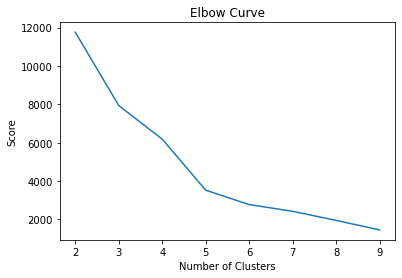

In [42]:
import pylab as pl
cluster = range(2,10)
cost_ = cost[2:]
pl.plot(cluster, cost_)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

## Build clustering model and make prediction

In [43]:
KMeans_algo = KMeans(featuresCol='standardized', k=5)
KMeans_fit = KMeans_algo.fit(data_scale_output)

preds = KMeans_fit.transform(data_scale_output)
preds.show(5,0)

+-------+---------+------------------+----------+-----------------------------------+-------------------------------------------------------------+----------+
|recency|frequency|monetary_value    |CustomerID|features                           |standardized                                                 |prediction|
+-------+---------+------------------+----------+-----------------------------------+-------------------------------------------------------------+----------+
|4586760|10       |153.0             |17714     |[4586760.0,10.0,153.0]             |[0.5258889381294373,0.25819728443703055,0.05473295319730301] |1         |
|9700860|10       |163.3             |16250     |[9700860.0,10.0,163.3]             |[1.1122393507273833,0.25819728443703055,0.058417589915814264]|1         |
|1230360|43       |306.84            |17551     |[1230360.0,43.0,306.84]            |[0.14106530839131204,1.1102483230792313,0.10976640103961081] |1         |
|3148260|37       |236.01999999999995|13187   

# cluster analysis

In [51]:
df_viz = preds.select('recency','frequency','monetary_value','prediction').toPandas()
avg_df = df_viz.groupby(['prediction']).mean()
avg_df.head()

,recency,frequency,monetary_value
prediction,,,
0,2.875878e+07,22.244281,397.104460
1,1.088840e+07,16.254740,286.476801
2,3.223086e+07,1.000000,-168469.600000
3,2.778747e+07,242.831325,2623.059759
4,4.153860e+06,1.000000,-77183.600000


In [52]:
dx = avg_df.stack().reset_index().set_axis(['prediction', 'typ', 'val'], axis=1)
dx.head()

,prediction,typ,val
0,0,recency,2.875878e+07
1,0,frequency,2.224428e+01
2,0,monetary_value,3.971045e+02
3,1,recency,1.088840e+07
4,1,frequency,1.625474e+01


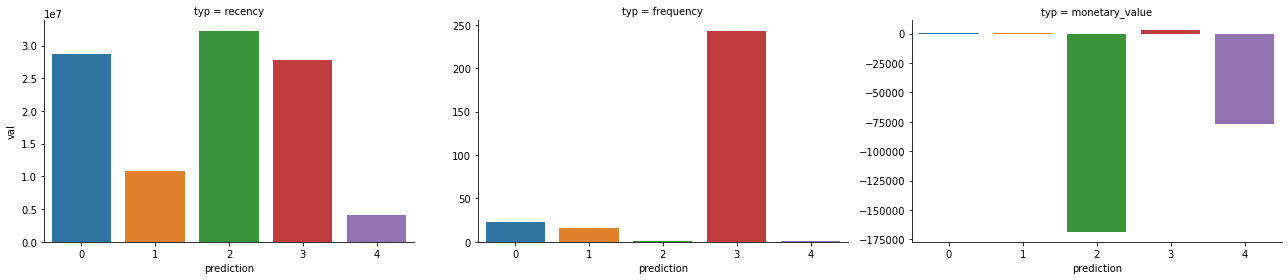

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.catplot(
    kind='bar',
    data=dx,
    x='prediction',
    y='val',
    col='typ',
    sharey=False,
    # ci=None,                  #remove error bars
    height=4,
    aspect=1.5,
)

# create df

In [93]:
cols = ['language','user_count']
data = [
    ('Java', 20000), 
    ('Python', 100000), 
    ('Scala', 3000),
]
schema = StructType([ 
    StructField('language', StringType(), True), 
    StructField('user_count', IntegerType(), True),
])

## from rdd

In [94]:
rdd = spark.sparkContext.parallelize(data)

In [95]:
t0 = time.time()
d1 = rdd.toDF(cols)
d1.show(5,0)
print(f'time: {time.time() - t0:.3f}')
# time: 18.728

+--------+----------+
|language|user_count|
+--------+----------+
|Java    |20000     |
|Python  |100000    |
|Scala   |3000      |
+--------+----------+

time: 20.895


In [96]:
t0 = time.time()
d2 = spark.createDataFrame(rdd, schema=cols)
d2.show(5,0)
print(f'time: {time.time() - t0:.3f}')
# time: 18.494

+--------+----------+
|language|user_count|
+--------+----------+
|Java    |20000     |
|Python  |100000    |
|Scala   |3000      |
+--------+----------+

time: 19.314


## from list

In [97]:
t0 = time.time()
d3 = spark.createDataFrame(data=data, schema=schema)
d3.show(5,0)
print(f'time: {time.time() - t0:.3f}')
# time: 9.046

+--------+----------+
|language|user_count|
+--------+----------+
|Java    |20000     |
|Python  |100000    |
|Scala   |3000      |
+--------+----------+

time: 10.001


In [71]:
t0 = time.time()
df = spark.createDataFrame(spark.sparkContext.emptyRDD(), schema)
df.show(5,0)
print(f'time: {time.time() - t0:.3f}')

+--------+----------+
|language|user_count|
+--------+----------+
+--------+----------+

time: 0.130


In [106]:
t0 = time.time()
df = spark.createDataFrame([], schema)
df.show(5,0)
print(f'time: {time.time() - t0:.3f}')

+--------+----------+
|language|user_count|
+--------+----------+
+--------+----------+

time: 20.143
